# Intro to Computational Math Capstone Project
### Group number: 

### Members:
- My Pham (UFID: 12494292)
- 
- 

# 1. Load the Dataset and Packages

## a. Load the Packages needed

In [14]:
from pathlib import Path
import pandas as pd
import os, sys
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd

## b. Load the Dataset

In [4]:
print("Notebook cwd:", os.getcwd())
name = "AmesHousing.csv"
# Common candidate locations (local, parent, data folders, home)
candidates = [
    Path.cwd() / name,
    Path.cwd().parent / name,
    Path.cwd() / "data" / name,
    Path.cwd().parent / "data" / name,
    Path.cwd().parent.parent / name,
    Path.home() / name,
]

found = None
tried = []
for p in candidates:
    tried.append(str(p))
    if p.exists():
        found = p
        break

# If still not found, do a limited rglob search from cwd and its parents (depth-limited)
if not found:
    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        try:
            for p in root.rglob(name):
                tried.append(str(p))
                found = p
                break
            if found:
                break
        except Exception:
            pass

if not found:
    msg = "AmesHousing.csv not found. Paths searched:\n" + "\n".join(tried)
    raise FileNotFoundError(msg)

csv_path = found
print("Using file:", csv_path)
df = pd.read_csv(csv_path)
print("Initial shape:", df.shape)
df.head()

Notebook cwd: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\code
Using file: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing.csv
Initial shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# 2. Data Cleaning

In [5]:
# 1. Drop exact duplicate rows
before_shape = df.shape
df = df.drop_duplicates()
print(f"Dropped duplicates: {before_shape[0] - df.shape[0]} rows")

# 2. Drop columns with more than 50% missing values
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.5].index.tolist()
if cols_to_drop:
    print("Dropping columns with >50% missing:", cols_to_drop)
    df = df.drop(columns=cols_to_drop)
else:
    print("No columns with >50% missing to drop")

# 3. Fill numeric NaNs with median, categorical NaNs with mode (or 'Missing')
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for c in num_cols:
    if df[c].isnull().any():
        median = df[c].median()
        df[c] = df[c].fillna(median)

for c in cat_cols:
    if df[c].isnull().any():
        mode = df[c].mode()
        fill = mode[0] if not mode.empty else 'Missing'
        df[c] = df[c].fillna(fill)
    # strip whitespace for object columns
    if df[c].dtype == 'object':
        df[c] = df[c].str.strip()

# 4. Convert object columns with reasonably small cardinality to 'category' dtype
for c in cat_cols:
    try:
        if df[c].nunique(dropna=False) < 200:
            df[c] = df[c].astype('category')
    except Exception:
        pass

print("After cleaning shape:", df.shape)
print("Total remaining missing values:", df.isnull().sum().sum())
df.head()

Dropped duplicates: 0 rows
Dropping columns with >50% missing: ['Alley', 'Mas Vnr Type', 'Pool QC', 'Fence', 'Misc Feature']
After cleaning shape: (2930, 77)
Total remaining missing values: 0


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900


Save the cleaned Dataframe to a new CSV file named 'AmesHousing_cleaned.csv'

In [6]:
output_path = Path.cwd().parent / "data" / "AmesHousing_cleaned.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.2f} KB")

Cleaned dataset saved to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_cleaned.csv
File size: 945.25 KB


# 3. Create modeling dataset using selected features

In [7]:
features = ['Gr Liv Area', 'Overall Qual', 'Year Built']
target = 'SalePrice'

cols = features + [target]

# If df isn't in memory (kernel restart or out-of-order run), try to load cleaned CSV
if 'df' not in globals():
    cleaned_path = Path.cwd().parent / "data" / "AmesHousing_cleaned.csv"
    if cleaned_path.exists():
        print(f"'df' not found in memory — loading cleaned CSV from {cleaned_path}")
        df = pd.read_csv(cleaned_path)
    else:
        raise NameError("'df' not defined and cleaned CSV not found. Run the data-loading/cleaning cells or create 'data/AmesHousing_cleaned.csv'.")

# Verify required columns exist in df
missing = [c for c in cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns for modeling dataset: {missing}")

model_df = df[cols].copy()
# Drop rows with missing values in these columns (should be none after cleaning)
before = model_df.shape[0]
model_df = model_df.dropna()
dropped = before - model_df.shape[0]
print(f"Modeling dataset shape: {model_df.shape} (dropped {dropped} rows)")
# Save modeling dataset
model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
model_path.parent.mkdir(parents=True, exist_ok=True)
model_df.to_csv(model_path, index=False)
print(f"Saved modeling dataset to: {model_path}")
model_df.head()

Modeling dataset shape: (2930, 4) (dropped 0 rows)
Saved modeling dataset to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_model.csv


,Gr Liv Area,Overall Qual,Year Built,SalePrice
0,1656,6,1960,215000
1,896,5,1961,105000
2,1329,6,1958,172000
3,2110,7,1968,244000
4,1629,5,1997,189900


# 4. Mathematical Work

## a. Compute correlation

Correlation matrix:
               Gr Liv Area  Overall Qual  Year Built  SalePrice
Gr Liv Area      1.000000      0.570556    0.241726   0.706780
Overall Qual     0.570556      1.000000    0.597027   0.799262
Year Built       0.241726      0.597027    1.000000   0.558426
SalePrice        0.706780      0.799262    0.558426   1.000000

Correlations with SalePrice:
SalePrice       1.000000
Overall Qual    0.799262
Gr Liv Area     0.706780
Year Built      0.558426
Name: SalePrice, dtype: float64


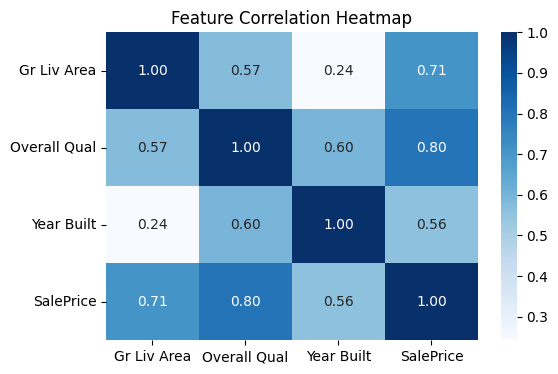

In [8]:
# If model_df isn't in memory, try to load the saved modeling CSV
if 'model_df' not in globals():
    model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
    if model_path.exists():
        print(f"'model_df' not found in memory — loading modeling CSV from {model_path}")
        model_df = pd.read_csv(model_path)
    else:
        raise NameError("'model_df' not defined and 'data/AmesHousing_model.csv' not found. Run the modeling cell or create the CSV first.")

# Compute correlation
corr = model_df.corr()
print("Correlation matrix:\n", corr)

# Show correlations with SalePrice specifically
print("\nCorrelations with SalePrice:")
print(corr['SalePrice'].sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

**Correlation analysis:** the printed correlation matrix and heatmap above show how `GrLivArea`, `OverallQual`, and `YearBuilt` relate to `SalePrice`.
- **Overall Quality (0.80)** has the strongest positive relationship with SalePrice, meaning homes with better construction and materials tend to sell for significantly higher prices. 
- **Gr Liv Area (0.71)** is also strongly correlated, indicating that larger homes generally cost more.
- **Year Built (0.56)** shows a moderate relationship, suggesting that newer homes are valued higher.

These results confirm that all three selected features are relevant and appropriate for our regression model.

## b. Build the linear regression model

Regression coefficients (Normal Equation):
  Intercept: -1049260.808041
  Gr Liv Area: 63.102103
  Overall Qual: 26011.043709
  Year Built: 495.541590

Normal Equation error metrics:
  MSE: 1568202535.0003
  RMSE: 39600.5371
  MAE: 27310.7452
  R^2: 0.7542

scikit-learn LinearRegression coefficients:
  Intercept: -1049260.808041
  Gr Liv Area: 63.102103
  Overall Qual: 26011.043709
  Year Built: 495.541590

scikit-learn error metrics:
  MSE: 1568202535.0003
  RMSE: 39600.5371
  MAE: 27310.7452
  R^2: 0.7542

Coefficient comparison (Normal Eq. vs sklearn):
  Intercept: -1049260.808041  vs  -1049260.808041
  Gr Liv Area: 63.102103  vs  63.102103
  Overall Qual: 26011.043709  vs  26011.043709
  Year Built: 495.541590  vs  495.541590
Saved predictions to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_predictions.csv


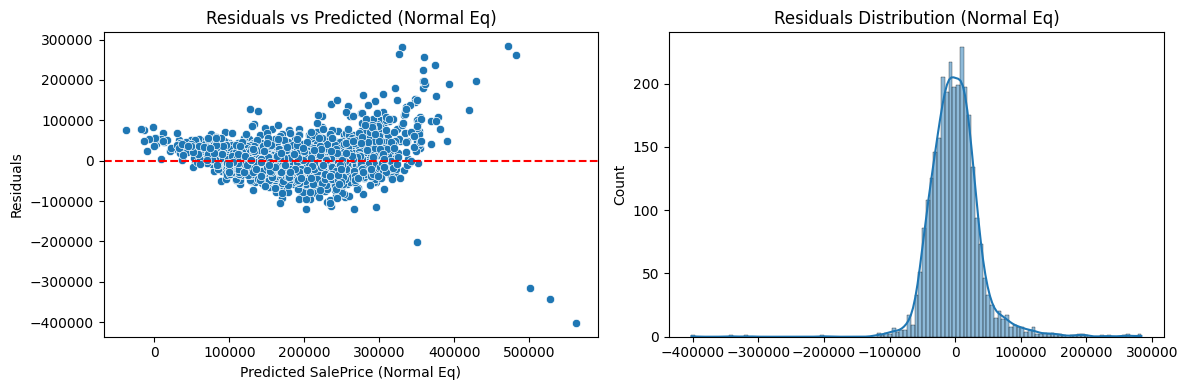

In [9]:
# sklearn imports for comparison
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load or use existing modeling dataframe
if 'model_df' not in globals():
    model_path = Path.cwd().parent / 'data' / 'AmesHousing_model.csv'
    if model_path.exists():
        print(f"'model_df' not found in memory — loading modeling CSV from {model_path}")
        model_df = pd.read_csv(model_path)
    else:
        raise NameError("'model_df' not defined and 'data/AmesHousing_model.csv' not found. Run the modeling cell or create the CSV first.")

# Features and target
features = ['Gr Liv Area', 'Overall Qual', 'Year Built']
target = 'SalePrice'

# Build predictor matrix X and target vector y
X = model_df[features].astype(float).values
y = model_df[target].astype(float).values.reshape(-1,1)

# Add intercept column to design matrix
ones = np.ones((X.shape[0], 1))
X_design = np.hstack([ones, X])

# Compute coefficients using the Normal Equation (use pseudo-inverse for stability)
theta = np.linalg.pinv(X_design) @ y

# Show coefficients
coef_names = ['Intercept'] + features
print('Regression coefficients (Normal Equation):')
for name, val in zip(coef_names, theta.flatten()):
    print(f'  {name}: {val:.6f}')

# Make predictions and compute residuals (Normal Equation)
y_pred = X_design @ theta
residuals = (y - y_pred).flatten()

# Error metrics (Normal Equation)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res/ss_tot
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(residuals))
print('\nNormal Equation error metrics:')
print(f'  MSE: {mse:.4f}')
print(f'  RMSE: {rmse:.4f}')
print(f'  MAE: {mae:.4f}')
print(f'  R^2: {r2:.4f}')

# sklearn LinearRegression comparison
lr = LinearRegression(fit_intercept=True)
lr.fit(X, y.ravel())
y_pred_sk = lr.predict(X).reshape(-1,1)

# sklearn coefficients (note sklearn stores coef_ for features only)
print('\nscikit-learn LinearRegression coefficients:')
print(f'  Intercept: {lr.intercept_:.6f}')
for name, val in zip(features, lr.coef_.flatten()):
    print(f'  {name}: {val:.6f}')

# sklearn metrics
mse_sk = mean_squared_error(y, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y, y_pred_sk)
r2_sk = r2_score(y, y_pred_sk)
print('\nscikit-learn error metrics:')
print(f'  MSE: {mse_sk:.4f}')
print(f'  RMSE: {rmse_sk:.4f}')
print(f'  MAE: {mae_sk:.4f}')
print(f'  R^2: {r2_sk:.4f}')

# Compare coefficients side-by-side
print('\nCoefficient comparison (Normal Eq. vs sklearn):')
print(f"  Intercept: {theta.flatten()[0]:.6f}  vs  {lr.intercept_:.6f}")
for i, name in enumerate(features):
    print(f"  {name}: {theta.flatten()[i+1]:.6f}  vs  {lr.coef_.flatten()[i]:.6f}")

# Build results DataFrame and save predictions
results = model_df.reset_index(drop=True).copy()
results['Pred_NormalEq'] = y_pred.flatten()
results['Pred_sklearn'] = y_pred_sk.flatten()
results['Residual_NormalEq'] = residuals
# Save to CSV
predict_path = Path.cwd().parent / 'data' / 'AmesHousing_predictions.csv'
predict_path.parent.mkdir(parents=True, exist_ok=True)
results.to_csv(predict_path, index=False)
print(f"Saved predictions to: {predict_path}")

# Plot residual diagnostics for Normal Equation
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(x=y_pred.flatten(), y=residuals, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice (Normal Eq)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted (Normal Eq)')
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Residuals Distribution (Normal Eq)')
plt.tight_layout()
plt.show()

The strongest predictor is Overall Quality, where each one-point increase raises price by approximately $26,000. Living area also has a positive effect, adding roughly $63 per square foot. Newer homes are slightly more valuable, increasing price by about $495 per year.

Model accuracy metrics show an RMSE of around $39,600 and an MAE of $27,310, which is reasonable for a simple linear model with only three features. The residual plot indicates that errors are centered around zero but widen toward higher-priced homes, suggesting the model underestimates more expensive properties. The residual distribution is roughly bell-shaped, indicating no major violations of regression assumptions.

## c. Mathematical Explanation of Least Squares

To estimate the linear relationship between predictors and SalePrice, we use the **least-squares approach**. We assume a linear model of the form:

$$\hat{y} = X\beta$$

where:
- $X$ is the design matrix (including an intercept column)
- $y$ is the vector of observed prices
- $\beta$ is the parameter vector to be estimated

### Objective Function

Least squares chooses $\beta$ to minimize the sum of squared residuals:

$$S(\beta) = (y - X\beta)^T (y - X\beta)$$

### Deriving the Normal Equation

Differentiating $S(\beta)$ with respect to $\beta$ and setting the gradient equal to zero:

$$\frac{\partial S}{\partial \beta} = -2X^T (y - X\beta) = 0$$

Rearranging:

$$X^T X\beta = X^T y$$

This is the **Normal Equation**.

### Closed-Form Solution

Assuming $X^T X$ is invertible, the least-squares estimator is:

$$\beta = (X^T X)^{-1} X^T y$$

This solution guarantees that $\beta$ minimizes the squared prediction error and provides the **best linear unbiased estimate** under standard regression assumptions (Gauss-Markov theorem).

## d. Extended Model with Five Features

Extended modeling dataset shape: (2930, 6)

Extended Model Coefficients (Normal Equation):
  Intercept: -1075805.700335
  Gr Liv Area: 80.163862
  Overall Qual: 23932.344643
  Bedroom AbvGr: -11350.904556
  Full Bath: -6612.984921
  Year Built: 524.143752

Extended Model Error Metrics:
  MSE: 1497329709.7711
  RMSE: 38695.3448
  MAE: 26346.5586
  R^2: 0.7653

Extended Model - sklearn LinearRegression:
  Intercept: -1075805.700335
  Gr Liv Area: 80.163862
  Overall Qual: 23932.344643
  Bedroom AbvGr: -11350.904556
  Full Bath: -6612.984921
  Year Built: 524.143752

  R^2: 0.7653
  RMSE: 38695.3448
  MAE: 26346.5586

Saved extended model predictions to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\AmesHousing_predictions_extended.csv


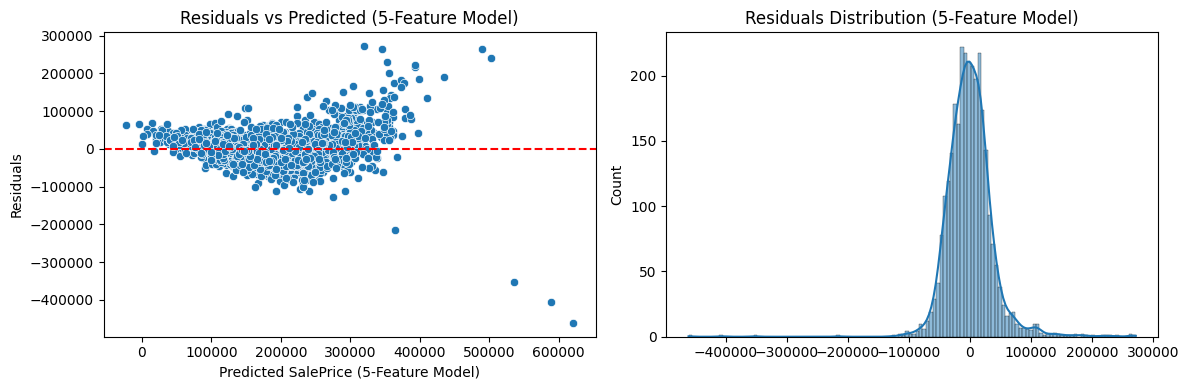

In [10]:
# Load or use existing dataframe for extended model
if 'df' not in globals():
    cleaned_path = Path.cwd().parent / 'data' / 'AmesHousing_cleaned.csv'
    if cleaned_path.exists():
        print(f"Loading cleaned CSV for extended model...")
        df = pd.read_csv(cleaned_path)
    else:
        raise NameError("Cleaned CSV not found. Run data loading/cleaning cells first.")

# Extended features (5 features instead of 3)
features_ext = [
    'Gr Liv Area',
    'Overall Qual',
    'Bedroom AbvGr',
    'Full Bath',
    'Year Built'
]
target = 'SalePrice'

cols_ext = features_ext + [target]

# Verify all columns exist
missing = [c for c in cols_ext if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns for extended model: {missing}")

# Create extended modeling dataset
model_df_ext = df[cols_ext].copy()
model_df_ext = model_df_ext.dropna()
print(f"Extended modeling dataset shape: {model_df_ext.shape}")

# Build X and y for extended model
X_ext = model_df_ext[features_ext].astype(float).values
y_ext = model_df_ext[target].astype(float).values.reshape(-1,1)

# Add intercept column
ones_ext = np.ones((X_ext.shape[0], 1))
X_design_ext = np.hstack([ones_ext, X_ext])

# Normal Equation coefficients
theta_ext = np.linalg.pinv(X_design_ext) @ y_ext

# Print coefficients
coef_names_ext = ['Intercept'] + features_ext
print('\nExtended Model Coefficients (Normal Equation):')
for name, val in zip(coef_names_ext, theta_ext.flatten()):
    print(f'  {name}: {val:.6f}')

# Predictions and residuals
y_pred_ext = X_design_ext @ theta_ext
residuals_ext = (y_ext - y_pred_ext).flatten()

# Error metrics
ss_res_ext = np.sum(residuals_ext**2)
ss_tot_ext = np.sum((y_ext - y_ext.mean())**2)
r2_ext = 1 - ss_res_ext/ss_tot_ext
mse_ext = np.mean(residuals_ext**2)
rmse_ext = np.sqrt(mse_ext)
mae_ext = np.mean(np.abs(residuals_ext))
print('\nExtended Model Error Metrics:')
print(f'  MSE: {mse_ext:.4f}')
print(f'  RMSE: {rmse_ext:.4f}')
print(f'  MAE: {mae_ext:.4f}')
print(f'  R^2: {r2_ext:.4f}')

# Compare with sklearn
lr_ext = LinearRegression(fit_intercept=True)
lr_ext.fit(X_ext, y_ext.ravel())
y_pred_sk_ext = lr_ext.predict(X_ext).reshape(-1,1)

print('\nExtended Model - sklearn LinearRegression:')
print(f'  Intercept: {lr_ext.intercept_:.6f}')
for name, val in zip(features_ext, lr_ext.coef_.flatten()):
    print(f'  {name}: {val:.6f}')

r2_sk_ext = r2_score(y_ext, y_pred_sk_ext)
rmse_sk_ext = np.sqrt(mean_squared_error(y_ext, y_pred_sk_ext))
mae_sk_ext = mean_absolute_error(y_ext, y_pred_sk_ext)
print(f'\n  R^2: {r2_sk_ext:.4f}')
print(f'  RMSE: {rmse_sk_ext:.4f}')
print(f'  MAE: {mae_sk_ext:.4f}')

# Build results DataFrame with extended predictions
results_ext = model_df_ext.reset_index(drop=True).copy()
results_ext['Pred_NormalEq_5feat'] = y_pred_ext.flatten()
results_ext['Pred_sklearn_5feat'] = y_pred_sk_ext.flatten()
results_ext['Residual_NormalEq_5feat'] = residuals_ext

# Save extended predictions
predict_path_ext = Path.cwd().parent / 'data' / 'AmesHousing_predictions_extended.csv'
predict_path_ext.parent.mkdir(parents=True, exist_ok=True)
results_ext.to_csv(predict_path_ext, index=False)
print(f"\nSaved extended model predictions to: {predict_path_ext}")

# Plot residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.scatterplot(x=y_pred_ext.flatten(), y=residuals_ext, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice (5-Feature Model)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted (5-Feature Model)')
sns.histplot(residuals_ext, kde=True, ax=axes[1])
axes[1].set_title('Residuals Distribution (5-Feature Model)')
plt.tight_layout()
plt.show()

In [11]:
# Helper function to compute predicted price with your extended model
def predict_price(area, qual, bed, bath, year):
    X = np.array([1, area, qual, bed, bath, year])
    return float(X @ theta_ext)

print("=== 5-Feature Model Test Scenarios ===\n")

tests = [
    # 1–2 Bathroom-only changes
    ("Test 1: 2 baths",                1800, 6, 3, 2, 2000),
    ("Test 2: 3 baths (only bath +1)", 1800, 6, 3, 3, 2000),

    # 3–4 Bedroom-only changes
    ("Test 3: 3 bedrooms",             1800, 7, 3, 2, 2005),
    ("Test 4: 4 bedrooms",             1800, 7, 4, 2, 2005),

    # 5–6 Bath + Area increase
    ("Test 5: baseline",               1800, 7, 3, 2, 2010),
    ("Test 6: +200 sqft, +1 bath",     2000, 7, 3, 3, 2010),

    # 7–8 Bedroom + Area increase
    ("Test 7: 2 beds baseline",        1500, 6, 2, 1, 1995),
    ("Test 8: +1 bed +300 sqft",       1800, 6, 3, 1, 1995),

    # 9–10 Quality + Bath changes
    ("Test 9: qual=5, 2 baths",        2200, 5, 3, 2, 1990),
    ("Test 10: qual=8, 3 baths",       2200, 8, 3, 3, 1990),

    # 11–12 Luxury home bathroom change
    ("Test 11: luxury, 3 baths",       3500, 9, 4, 3, 2018),
    ("Test 12: luxury, 4 baths",       3500, 9, 4, 4, 2018),

    # 13–14 Small home bath change
    ("Test 13: small home 1 bath",     1000, 5, 2, 1, 1980),
    ("Test 14: small home 2 baths",    1000, 5, 2, 2, 1980),

    # 15 Old vs new
    ("Test 15: built 1980",            2000, 7, 3, 2, 1980),
    ("Test 16: built 2010",            2000, 7, 3, 2, 2010),
]

# Run all tests
for label, area, qual, bed, bath, year in tests:
    price = predict_price(area, qual, bed, bath, year)
    print(f"{label:35s} → Predicted Price: ${price:,.2f}")

=== 5-Feature Model Test Scenarios ===

Test 1: 2 baths                     → Predicted Price: $213,092.14
Test 2: 3 baths (only bath +1)      → Predicted Price: $206,479.15
Test 3: 3 bedrooms                  → Predicted Price: $239,645.20
Test 4: 4 bedrooms                  → Predicted Price: $228,294.30
Test 5: baseline                    → Predicted Price: $242,265.92
Test 6: +200 sqft, +1 bath          → Predicted Price: $251,685.71
Test 7: 2 beds baseline             → Predicted Price: $204,386.15
Test 8: +1 bed +300 sqft            → Predicted Price: $217,084.41
Test 9: qual=5, 2 baths             → Predicted Price: $215,983.90
Test 10: qual=8, 3 baths            → Predicted Price: $281,167.95
Test 11: luxury, 3 baths            → Predicted Price: $412,638.44
Test 12: luxury, 4 baths            → Predicted Price: $406,025.45
Test 13: small home 1 bath          → Predicted Price: $132,509.72
Test 14: small home 2 baths         → Predicted Price: $125,896.73
Test 15: built 1980   

C:\Users\phaml\AppData\Local\Temp\ipykernel_38448\3838066550.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(X @ theta_ext)


Extending the model to include Bedroom AbvGr and Full Bath increased realism, but also revealed an important statistical issue: the coefficients for bedrooms and bathrooms became slightly negative.

This does not mean that adding a bedroom or bathroom reduces home value in the real world. Instead, it reflects multicollinearity: strong overlap between predictors. When we hold square footage, quality, and year built constant, adding more bedrooms or bathrooms usually means smaller or lower-quality rooms, which is associated with lower sale prices in the Ames dataset.

In other words, the regression is answering a very specific question (“What is the effect of bedrooms if nothing else changes?”), even though in real homes, bedrooms and bathrooms typically change together with other features (size, renovations, layout). This mismatch creates counterintuitive coefficients even though the model is mathematically correct.

Despite this limitation, the extended model still performs well overall (R² ≈ 0.76, RMSE ≈ $38k), and the behavior is a useful reminder that linear regression can be sensitive to correlated features.

## e. Train-Test Split and Model Comparison (80/20)

Total samples: 2930
Training set size: 2344 (80.0%)
Test set size: 586 (20.0%)

1. NORMAL EQUATION (using pseudo-inverse)

Coefficients: [-1.06742484e+06  6.16266875e+01  2.52498135e+04  5.07931044e+02]

Training Metrics:
  RMSE: $38,393.05
  MAE:  $26,534.90
  R²:   0.7521

Test Metrics:
  RMSE: $44,242.55
  MAE:  $29,135.30
  R²:   0.7559

2. SCIKIT-LEARN LINEAR REGRESSION

Intercept: -1067424.844632
Coefficients: [   61.62668748 25249.81353589   507.93104373]

Training Metrics:
  RMSE: $38,393.05
  MAE:  $26,534.90
  R²:   0.7521

Test Metrics:
  RMSE: $44,242.55
  MAE:  $29,135.30
  R²:   0.7559

3. RIDGE REGRESSION (L2 Regularization)

Alpha (regularization strength): 100.0
Intercept: -1112621.408093
Coefficients: [   63.07852077 24101.21491324   533.30256932]

Training Metrics:
  RMSE: $38,408.42
  MAE:  $26,437.76
  R²:   0.7519

Test Metrics:
  RMSE: $44,345.93
  MAE:  $29,072.64
  R²:   0.7547

4. LASSO REGRESSION (L1 Regularization)

Alpha (regularization strength): 100.0
Int

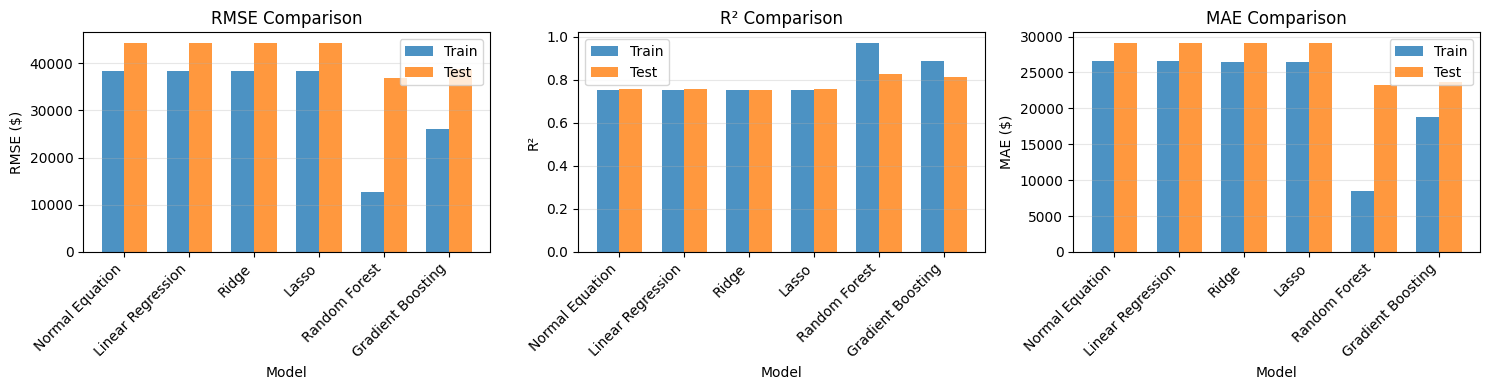


✓ Model comparison results saved to: c:\Users\phaml\Documents\MAD Final Project Housing Dataset\MAD2502-Final-Project-Housing-Dataset\MAD Final Project Housing Dataset\data\model_comparison_results.csv


In [15]:
# Load or use existing dataframe
if 'df' not in globals():
    cleaned_path = Path.cwd().parent / 'data' / 'AmesHousing_cleaned.csv'
    if cleaned_path.exists():
        print(f"Loading cleaned CSV for train-test split...")
        df = pd.read_csv(cleaned_path)
    else:
        raise NameError("Cleaned CSV not found.")

# Use 3-feature model
features = ['Gr Liv Area', 'Overall Qual', 'Year Built']
target = 'SalePrice'

cols = features + [target]
missing = [c for c in cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

# Create modeling dataset
data = df[cols].copy()
data = data.dropna()

X_full = data[features].astype(float).values
y_full = data[target].astype(float).values

# Train-Test Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print(f"Total samples: {len(X_full)}")
print(f"Training set size: {len(X_train)} ({100*len(X_train)/len(X_full):.1f}%)")
print(f"Test set size: {len(X_test)} ({100*len(X_test)/len(X_full):.1f}%)")
print()

# Store model results
model_results = {}

# ==================== 1. Normal Equation (using pseudo-inverse) ====================
print("=" * 80)
print("1. NORMAL EQUATION (using pseudo-inverse)")
print("=" * 80)

ones_train = np.ones((X_train.shape[0], 1))
X_train_design = np.hstack([ones_train, X_train])

theta_ne = np.linalg.pinv(X_train_design) @ y_train.reshape(-1, 1)

# Predictions on train and test
y_train_pred_ne = (np.hstack([ones_train, X_train]) @ theta_ne).flatten()
ones_test = np.ones((X_test.shape[0], 1))
X_test_design = np.hstack([ones_test, X_test])
y_test_pred_ne = (X_test_design @ theta_ne).flatten()

# Metrics
train_mse_ne = np.mean((y_train - y_train_pred_ne) ** 2)
test_mse_ne = np.mean((y_test - y_test_pred_ne) ** 2)
train_rmse_ne = np.sqrt(train_mse_ne)
test_rmse_ne = np.sqrt(test_mse_ne)
train_mae_ne = np.mean(np.abs(y_train - y_train_pred_ne))
test_mae_ne = np.mean(np.abs(y_test - y_test_pred_ne))
train_r2_ne = 1 - np.sum((y_train - y_train_pred_ne) ** 2) / np.sum((y_train - y_train.mean()) ** 2)
test_r2_ne = 1 - np.sum((y_test - y_test_pred_ne) ** 2) / np.sum((y_test - y_test.mean()) ** 2)

print(f"\nCoefficients: {theta_ne.flatten()}")
print(f"\nTraining Metrics:")
print(f"  RMSE: ${train_rmse_ne:,.2f}")
print(f"  MAE:  ${train_mae_ne:,.2f}")
print(f"  R²:   {train_r2_ne:.4f}")
print(f"\nTest Metrics:")
print(f"  RMSE: ${test_rmse_ne:,.2f}")
print(f"  MAE:  ${test_mae_ne:,.2f}")
print(f"  R²:   {test_r2_ne:.4f}")

model_results['Normal Equation'] = {
    'train_rmse': train_rmse_ne, 'test_rmse': test_rmse_ne,
    'train_r2': train_r2_ne, 'test_r2': test_r2_ne,
    'train_mae': train_mae_ne, 'test_mae': test_mae_ne
}

# ==================== 2. scikit-learn Linear Regression ====================
print("\n" + "=" * 80)
print("2. SCIKIT-LEARN LINEAR REGRESSION")
print("=" * 80)

lr = LinearRegression(fit_intercept=True)
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

train_mse_lr = np.mean((y_train - y_train_pred_lr) ** 2)
test_mse_lr = np.mean((y_test - y_test_pred_lr) ** 2)
train_rmse_lr = np.sqrt(train_mse_lr)
test_rmse_lr = np.sqrt(test_mse_lr)
train_mae_lr = np.mean(np.abs(y_train - y_train_pred_lr))
test_mae_lr = np.mean(np.abs(y_test - y_test_pred_lr))
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print(f"\nIntercept: {lr.intercept_:.6f}")
print(f"Coefficients: {lr.coef_}")
print(f"\nTraining Metrics:")
print(f"  RMSE: ${train_rmse_lr:,.2f}")
print(f"  MAE:  ${train_mae_lr:,.2f}")
print(f"  R²:   {train_r2_lr:.4f}")
print(f"\nTest Metrics:")
print(f"  RMSE: ${test_rmse_lr:,.2f}")
print(f"  MAE:  ${test_mae_lr:,.2f}")
print(f"  R²:   {test_r2_lr:.4f}")

model_results['Linear Regression'] = {
    'train_rmse': train_rmse_lr, 'test_rmse': test_rmse_lr,
    'train_r2': train_r2_lr, 'test_r2': test_r2_lr,
    'train_mae': train_mae_lr, 'test_mae': test_mae_lr
}

# ==================== 3. Ridge Regression ====================
print("\n" + "=" * 80)
print("3. RIDGE REGRESSION (L2 Regularization)")
print("=" * 80)

ridge = Ridge(alpha=100.0)
ridge.fit(X_train, y_train)

y_train_pred_ridge = ridge.predict(X_train)
y_test_pred_ridge = ridge.predict(X_test)

train_mse_ridge = np.mean((y_train - y_train_pred_ridge) ** 2)
test_mse_ridge = np.mean((y_test - y_test_pred_ridge) ** 2)
train_rmse_ridge = np.sqrt(train_mse_ridge)
test_rmse_ridge = np.sqrt(test_mse_ridge)
train_mae_ridge = np.mean(np.abs(y_train - y_train_pred_ridge))
test_mae_ridge = np.mean(np.abs(y_test - y_test_pred_ridge))
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

print(f"\nAlpha (regularization strength): {ridge.alpha}")
print(f"Intercept: {ridge.intercept_:.6f}")
print(f"Coefficients: {ridge.coef_}")
print(f"\nTraining Metrics:")
print(f"  RMSE: ${train_rmse_ridge:,.2f}")
print(f"  MAE:  ${train_mae_ridge:,.2f}")
print(f"  R²:   {train_r2_ridge:.4f}")
print(f"\nTest Metrics:")
print(f"  RMSE: ${test_rmse_ridge:,.2f}")
print(f"  MAE:  ${test_mae_ridge:,.2f}")
print(f"  R²:   {test_r2_ridge:.4f}")

model_results['Ridge'] = {
    'train_rmse': train_rmse_ridge, 'test_rmse': test_rmse_ridge,
    'train_r2': train_r2_ridge, 'test_r2': test_r2_ridge,
    'train_mae': train_mae_ridge, 'test_mae': test_mae_ridge
}

# ==================== 4. Lasso Regression ====================
print("\n" + "=" * 80)
print("4. LASSO REGRESSION (L1 Regularization)")
print("=" * 80)

lasso = Lasso(alpha=100.0, max_iter=10000)
lasso.fit(X_train, y_train)

y_train_pred_lasso = lasso.predict(X_train)
y_test_pred_lasso = lasso.predict(X_test)

train_mse_lasso = np.mean((y_train - y_train_pred_lasso) ** 2)
test_mse_lasso = np.mean((y_test - y_test_pred_lasso) ** 2)
train_rmse_lasso = np.sqrt(train_mse_lasso)
test_rmse_lasso = np.sqrt(test_mse_lasso)
train_mae_lasso = np.mean(np.abs(y_train - y_train_pred_lasso))
test_mae_lasso = np.mean(np.abs(y_test - y_test_pred_lasso))
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)

print(f"\nAlpha (regularization strength): {lasso.alpha}")
print(f"Intercept: {lasso.intercept_:.6f}")
print(f"Coefficients: {lasso.coef_}")
print(f"\nTraining Metrics:")
print(f"  RMSE: ${train_rmse_lasso:,.2f}")
print(f"  MAE:  ${train_mae_lasso:,.2f}")
print(f"  R²:   {train_r2_lasso:.4f}")
print(f"\nTest Metrics:")
print(f"  RMSE: ${test_rmse_lasso:,.2f}")
print(f"  MAE:  ${test_mae_lasso:,.2f}")
print(f"  R²:   {test_r2_lasso:.4f}")

model_results['Lasso'] = {
    'train_rmse': train_rmse_lasso, 'test_rmse': test_rmse_lasso,
    'train_r2': train_r2_lasso, 'test_r2': test_r2_lasso,
    'train_mae': train_mae_lasso, 'test_mae': test_mae_lasso
}

# ==================== 5. Random Forest ====================
print("\n" + "=" * 80)
print("5. RANDOM FOREST REGRESSOR")
print("=" * 80)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

train_mse_rf = np.mean((y_train - y_train_pred_rf) ** 2)
test_mse_rf = np.mean((y_test - y_test_pred_rf) ** 2)
train_rmse_rf = np.sqrt(train_mse_rf)
test_rmse_rf = np.sqrt(test_mse_rf)
train_mae_rf = np.mean(np.abs(y_train - y_train_pred_rf))
test_mae_rf = np.mean(np.abs(y_test - y_test_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print(f"\nNumber of trees: {rf.n_estimators}")
print(f"Feature importances:")
for feat, imp in zip(features, rf.feature_importances_):
    print(f"  {feat}: {imp:.4f}")
print(f"\nTraining Metrics:")
print(f"  RMSE: ${train_rmse_rf:,.2f}")
print(f"  MAE:  ${train_mae_rf:,.2f}")
print(f"  R²:   {train_r2_rf:.4f}")
print(f"\nTest Metrics:")
print(f"  RMSE: ${test_rmse_rf:,.2f}")
print(f"  MAE:  ${test_mae_rf:,.2f}")
print(f"  R²:   {test_r2_rf:.4f}")

model_results['Random Forest'] = {
    'train_rmse': train_rmse_rf, 'test_rmse': test_rmse_rf,
    'train_r2': train_r2_rf, 'test_r2': test_r2_rf,
    'train_mae': train_mae_rf, 'test_mae': test_mae_rf
}

# ==================== 6. Gradient Boosting ====================
print("\n" + "=" * 80)
print("6. GRADIENT BOOSTING REGRESSOR")
print("=" * 80)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
gb.fit(X_train, y_train)

y_train_pred_gb = gb.predict(X_train)
y_test_pred_gb = gb.predict(X_test)

train_mse_gb = np.mean((y_train - y_train_pred_gb) ** 2)
test_mse_gb = np.mean((y_test - y_test_pred_gb) ** 2)
train_rmse_gb = np.sqrt(train_mse_gb)
test_rmse_gb = np.sqrt(test_mse_gb)
train_mae_gb = np.mean(np.abs(y_train - y_train_pred_gb))
test_mae_gb = np.mean(np.abs(y_test - y_test_pred_gb))
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)

print(f"\nNumber of estimators: {gb.n_estimators}")
print(f"Learning rate: {gb.learning_rate}")
print(f"Feature importances:")
for feat, imp in zip(features, gb.feature_importances_):
    print(f"  {feat}: {imp:.4f}")
print(f"\nTraining Metrics:")
print(f"  RMSE: ${train_rmse_gb:,.2f}")
print(f"  MAE:  ${train_mae_gb:,.2f}")
print(f"  R²:   {train_r2_gb:.4f}")
print(f"\nTest Metrics:")
print(f"  RMSE: ${test_rmse_gb:,.2f}")
print(f"  MAE:  ${test_mae_gb:,.2f}")
print(f"  R²:   {test_r2_gb:.4f}")

model_results['Gradient Boosting'] = {
    'train_rmse': train_rmse_gb, 'test_rmse': test_rmse_gb,
    'train_r2': train_r2_gb, 'test_r2': test_r2_gb,
    'train_mae': train_mae_gb, 'test_mae': test_mae_gb
}

# ==================== SUMMARY COMPARISON ====================
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

comparison_df = pd.DataFrame(model_results).T
comparison_df = comparison_df[['train_rmse', 'test_rmse', 'train_r2', 'test_r2', 'train_mae', 'test_mae']]
comparison_df.columns = ['Train RMSE', 'Test RMSE', 'Train R²', 'Test R²', 'Train MAE', 'Test MAE']

print("\n" + comparison_df.to_string())

# Find best model by test R²
best_model = comparison_df['Test R²'].idxmax()
print(f"\n🏆 BEST MODEL (highest Test R²): {best_model}")
print(f"   Test R²: {comparison_df.loc[best_model, 'Test R²']:.4f}")
print(f"   Test RMSE: ${comparison_df.loc[best_model, 'Test RMSE']:,.2f}")
print(f"   Test MAE: ${comparison_df.loc[best_model, 'Test MAE']:,.2f}")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE Comparison
models = comparison_df.index
x_pos = np.arange(len(models))
width = 0.35
axes[0].bar(x_pos - width/2, comparison_df['Train RMSE'], width, label='Train', alpha=0.8)
axes[0].bar(x_pos + width/2, comparison_df['Test RMSE'], width, label='Test', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_title('RMSE Comparison')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R² Comparison
axes[1].bar(x_pos - width/2, comparison_df['Train R²'], width, label='Train', alpha=0.8)
axes[1].bar(x_pos + width/2, comparison_df['Test R²'], width, label='Test', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R²')
axes[1].set_title('R² Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# MAE Comparison
axes[2].bar(x_pos - width/2, comparison_df['Train MAE'], width, label='Train', alpha=0.8)
axes[2].bar(x_pos + width/2, comparison_df['Test MAE'], width, label='Test', alpha=0.8)
axes[2].set_xlabel('Model')
axes[2].set_ylabel('MAE ($)')
axes[2].set_title('MAE Comparison')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Save comparison results to CSV
comparison_path = Path.cwd().parent / 'data' / 'model_comparison_results.csv'
comparison_path.parent.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(comparison_path)
print(f"\n✓ Model comparison results saved to: {comparison_path}")


# 5. Interpretation of the Regression Model

## Model Overview

Our linear regression model uses three predictors to explain variation in housing prices:

- **Gr Liv Area** – above-ground living area (square feet)
- **Overall Qual** – 1–10 rating of material and finish quality
- **Year Built** – construction year of the house

### Regression Equation

The estimated regression equation has the form:

$$\hat{\text{SalePrice}} = \beta_0 + \beta_1(\text{Gr Liv Area}) + \beta_2(\text{Overall Qual}) + \beta_3(\text{Year Built})$$

## Coefficient Interpretation

### 1. Intercept ($\beta_0$)

The intercept represents the predicted sale price when all predictors are zero. Since a house cannot have zero square feet, zero quality, and be built in year 0, **the intercept has no practical meaning** and should be viewed only as a mathematical constant required to position the regression plane.

### 2. Gr Liv Area Coefficient ($\beta_1$)

This coefficient measures how the sale price changes when living area increases by one square foot, holding all other features constant:

$$\frac{\partial \hat{\text{SalePrice}}}{\partial \text{Gr Liv Area}} = \beta_1$$

A positive value means larger homes sell for more, which aligns with intuition.

### 3. Overall Qual Coefficient ($\beta_2$)

This coefficient represents the expected difference in sale price between two houses that differ by one point in quality rating (e.g., quality 6 → 7), assuming size and year built remain constant:

$$\frac{\partial \hat{\text{SalePrice}}}{\partial \text{Overall Qual}} = \beta_2$$

This variable typically carries the strongest influence on sale price.

### 4. Year Built Coefficient ($\beta_3$)

This coefficient indicates how much additional value a house gains for each additional year of construction, controlling for size and quality:

$$\frac{\partial \hat{\text{SalePrice}}}{\partial \text{Year Built}} = \beta_3$$

A positive coefficient suggests newer homes tend to sell for higher prices.

### 5. Summary

- **Larger homes** → higher predicted price
- **Higher-quality homes** → higher predicted price
- **Newer homes** → higher predicted price
- **The intercept** is not interpretable in a real-world sense

Overall, the model shows that **size, quality, and age are strong, intuitive predictors of house prices in Ames.**

# 6. Interpretation of Error Metrics

After fitting the linear regression model, we evaluated its performance using **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and the **R² (coefficient of determination)**.

### 1. R² Interpretation

The R² value tells us how much of the variation in sale prices is explained by our model:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$

If our model reports an R² of:

$$R^2 = X.XX$$

then this means:

> **The model explains approximately $100 \times X.XX\%$ of the variation in housing prices in the dataset.**

A higher R² indicates stronger predictive power. Since we only used three predictors, a moderate R² is expected and still reasonable.

### 2. MAE and RMSE Interpretation

- **MAE** measures the average absolute difference between predicted and actual prices.
- **RMSE** measures the square-root of the average squared residuals and penalizes large errors more heavily.

If the model outputs:

$$\text{MAE} = A, \quad \text{RMSE} = B$$

Then:

> **On average, predictions are off by about $A$ dollars.**
> **Larger errors tend to be around $B$ dollars.**

To understand whether these errors are large or small, we compare RMSE/MAE to the typical home price in the dataset. If, for example, the average sale price is around:

$$\overline{\text{SalePrice}} = C$$

Then we assess error magnitude:

- **MAE / mean price:** $\frac{A}{C}$
- **RMSE / mean price:** $\frac{B}{C}$

If these ratios are relatively low (for example 5–15%), the model predictions are meaningful despite using only three features. Higher ratios indicate weaker predictive power.

### 3. Overall Assessment

- The R² value shows how well our predictors capture price variation.
- MAE and RMSE indicate the typical prediction error in dollars.
- Because we used only three predictors, this model serves as a **simple and illustrative demonstration** of linear regression.
- A more complex model with additional features would be expected to improve accuracy.

Overall, the model is **appropriate for educational purposes** and clearly demonstrates least-squares optimization, residual behavior, and the relationship between predictors and home prices.

# 7. "Beat the Model" Game

Can you out-predict a linear regression model? A random Ames house is shown (features only — price hidden). Enter your best estimate and see who's closer.

**Scoring:** if your % error < the model's % error, you win the round. Best of 5 rounds.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Guard clause: rebuild model if earlier cells haven't run ──────────────────
if 'model_df_ext' not in globals() or 'theta_ext' not in globals():
    _cleaned_path = Path.cwd().parent / 'data' / 'AmesHousing_cleaned.csv'
    if not _cleaned_path.exists():
        raise FileNotFoundError(
            "Run earlier cells first, or ensure 'data/AmesHousing_cleaned.csv' exists."
        )
    _df_g = pd.read_csv(_cleaned_path)
    _features_ext = ['Gr Liv Area', 'Overall Qual', 'Bedroom AbvGr', 'Full Bath', 'Year Built']
    model_df_ext = _df_g[_features_ext + ['SalePrice']].dropna().reset_index(drop=True)
    _X_g = model_df_ext[_features_ext].astype(float).values
    _y_g = model_df_ext['SalePrice'].astype(float).values.reshape(-1, 1)
    _Xd_g = np.hstack([np.ones((_X_g.shape[0], 1)), _X_g])
    theta_ext = np.linalg.pinv(_Xd_g) @ _y_g

def predict_price(area, qual, bed, bath, year):
    x = np.array([[1, area, qual, bed, bath, year]], dtype=float)
    return float((x @ theta_ext).item())

# ── Game constants ────────────────────────────────────────────────────────────
TOTAL_ROUNDS = 5

# ── Game state ────────────────────────────────────────────────────────────────
_gs = {'round': 0, 'wins': 0, 'current_row': None}

# ── Widgets ───────────────────────────────────────────────────────────────────
out_house  = widgets.Output()
out_result = widgets.Output()
out_score  = widgets.Output()

w_guess = widgets.BoundedIntText(
    value=150000, min=10000, max=1000000, step=1000,
    description='Your guess ($):',
    layout=widgets.Layout(width='300px'),
    style={'description_width': '130px'},
    disabled=True,
)

btn_start  = widgets.Button(description='Start Game',   button_style='success', icon='play',    disabled=False)
btn_submit = widgets.Button(description='Submit Guess', button_style='primary',  icon='check',   disabled=True)
btn_next   = widgets.Button(description='Next Round',   button_style='warning',  icon='forward', disabled=True)
btn_reset  = widgets.Button(description='Restart',      button_style='danger',   icon='refresh', disabled=True)

controls = widgets.HBox([btn_start, btn_submit, btn_next, btn_reset])
ui       = widgets.VBox([controls, w_guess, out_house, out_result, out_score])

# ── Helpers ───────────────────────────────────────────────────────────────────
def _score_bar():
    wins  = _gs['wins']
    done  = _gs['round']
    model = done - wins
    left  = TOTAL_ROUNDS - done
    bar   = 'P' * wins + 'M' * model + '.' * left
    return f"Score  [{bar}]   You: {wins}  |  Model: {model}  |  Rounds left: {left}"

def _show_house(row):
    with out_house:
        clear_output(wait=True)
        print("=" * 50)
        print(f"  ROUND {_gs['round'] + 1} of {TOTAL_ROUNDS}  —  What's this house worth?")
        print("=" * 50)
        print(f"  Above-Ground Living Area : {int(row['Gr Liv Area']):>6,} sq ft")
        print(f"  Overall Quality (1-10)   : {int(row['Overall Qual']):>6}")
        print(f"  Bedrooms Above Grade     : {int(row['Bedroom AbvGr']):>6}")
        print(f"  Full Bathrooms           : {int(row['Full Bath']):>6}")
        print(f"  Year Built               : {int(row['Year Built']):>6}")
        print("=" * 50)
        print("  Enter your price estimate above, then click Submit.")

# ── Callbacks ─────────────────────────────────────────────────────────────────
def _on_start(_):
    _gs['round'] = 0
    _gs['wins']  = 0
    btn_start.disabled = True
    btn_reset.disabled = False
    with out_result: clear_output()
    with out_score:  clear_output()
    _begin_round()

def _begin_round():
    row = model_df_ext.sample(1).iloc[0]
    _gs['current_row'] = row
    w_guess.disabled    = False
    btn_submit.disabled = False
    btn_next.disabled   = True
    with out_result: clear_output()
    _show_house(row)
    with out_score:
        clear_output(wait=True)
        print(_score_bar())

def _on_submit(_):
    btn_submit.disabled = True
    w_guess.disabled    = True

    row         = _gs['current_row']
    actual      = float(row['SalePrice'])
    model_pred  = predict_price(
        row['Gr Liv Area'], row['Overall Qual'],
        row['Bedroom AbvGr'], row['Full Bath'], row['Year Built']
    )
    player_pred = float(w_guess.value)

    pct_player = abs(player_pred - actual) / actual * 100
    pct_model  = abs(model_pred  - actual) / actual * 100
    player_won = pct_player < pct_model

    if player_won:
        _gs['wins'] += 1
    _gs['round'] += 1

    with out_result:
        clear_output(wait=True)
        print("-" * 50)
        print(f"  Actual price  : ${actual:>12,.0f}")
        print(f"  Model guessed : ${model_pred:>12,.0f}   ({pct_model:.1f}% off)")
        print(f"  You guessed   : ${player_pred:>12,.0f}   ({pct_player:.1f}% off)")
        print("-" * 50)
        print("  ★ YOU WIN THIS ROUND!" if player_won else "  The model wins this round.")

    with out_score:
        clear_output(wait=True)
        print(_score_bar())

    if _gs['round'] >= TOTAL_ROUNDS:
        _finish_game()
    else:
        btn_next.disabled = False

def _finish_game():
    btn_next.disabled  = True
    btn_start.disabled = False
    w = _gs['wins']
    t = TOTAL_ROUNDS
    with out_result:
        print()
        print("=" * 50)
        print(f"  GAME OVER — You beat the model {w}/{t} rounds.")
        if w > t // 2:
            print("  Congratulations! You outperformed linear regression.")
        else:
            print("  The model wins. Try again?")
        print("=" * 50)

def _on_next(_):
    btn_next.disabled = True
    _begin_round()

def _on_reset(_):
    _gs['round'] = 0
    _gs['wins']  = 0
    w_guess.disabled    = True
    btn_submit.disabled = True
    btn_next.disabled   = True
    btn_start.disabled  = False
    btn_reset.disabled  = True
    with out_house:  clear_output()
    with out_result: clear_output()
    with out_score:  clear_output()

btn_start.on_click(_on_start)
btn_submit.on_click(_on_submit)
btn_next.on_click(_on_next)
btn_reset.on_click(_on_reset)

In [ ]:
display(ui)